In [1]:
from toric_spines_sim.events import (
    DeterministicEventGenerator,
    StochasticEventGenerator,
    FlatRateCurve,
    SineRateCurve,
)
from toric_spines_sim.viz import RasterPlotter
from toric_spines_sim.paths import DATA_DIR

rates_hz = [200, 400, 1000]
T_ms = 100.0
labels = ["A", "B", "C"]

# Define events data path using paths module
events_dir = DATA_DIR / "events"

/home/jordan/repos/toric_spines_sim/.venv/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(
/home/jordan/repos/toric_spines_sim/.venv/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


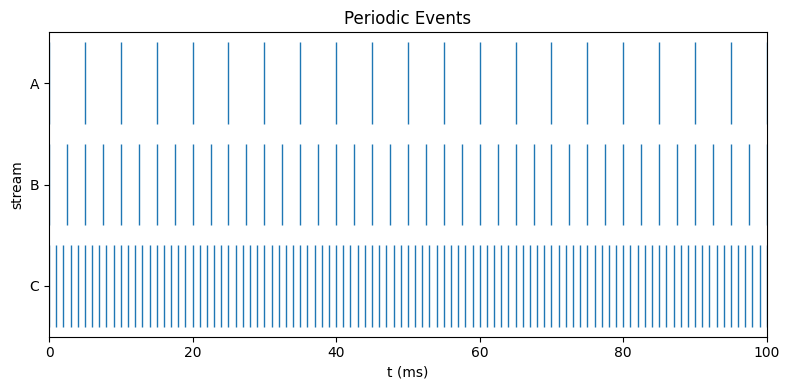

In [2]:
# ICPeriodicEvents -> DeterministicEventGenerator with FlatRateCurve (independent mode)
curves = [FlatRateCurve(r) for r in rates_hz]
gen = DeterministicEventGenerator(
    rate_curves=curves,
    n_synapses_per_axon=[1] * len(rates_hz),
    T_ms=T_ms,
    labels=labels,
)
gen.generate_to_file(events_dir / "demo_periodic.txt")  # writes labeled lines
events = DeterministicEventGenerator.load_from_file(events_dir / "demo_periodic.txt")
plotter = RasterPlotter(title="Periodic Events", xlim=(0.0, T_ms))
plotter.add_streams(events)
plotter.show()

/home/jordan/repos/toric_spines_sim/.venv/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(
/home/jordan/repos/toric_spines_sim/.venv/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


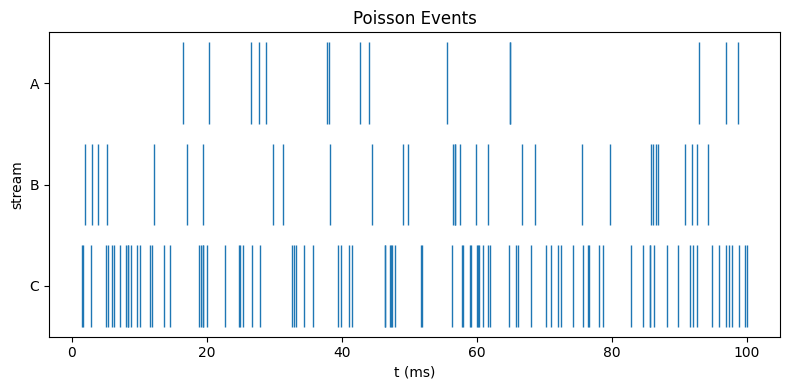

In [3]:
# ICPoissonEvents -> StochasticEventGenerator with FlatRateCurve (independent mode)
curves = [FlatRateCurve(r) for r in rates_hz]
gen = StochasticEventGenerator(
    rate_curves=curves,
    n_synapses_per_axon=[1] * len(rates_hz),
    T_ms=T_ms,
    seed=0,
    labels=labels,
)
gen.generate_to_file(events_dir / "demo_poisson.txt")
events = StochasticEventGenerator.load_from_file(events_dir / "demo_poisson.txt")
plotter = RasterPlotter(title="Poisson Events")
plotter.add_streams(events, linelength=0.8)
plotter.show()

# Shared-Source Event Generators

In shared-source generators, a single master process fires events that are
routed probabilistically through a set of axons. Each axon has one or more
synapses; when an axon is activated, *all* of its synapses receive the event
simultaneously.

## SSPoissonEvents

Shared-source Poisson: a single master Poisson process routes events to axons.

/home/jordan/repos/toric_spines_sim/.venv/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


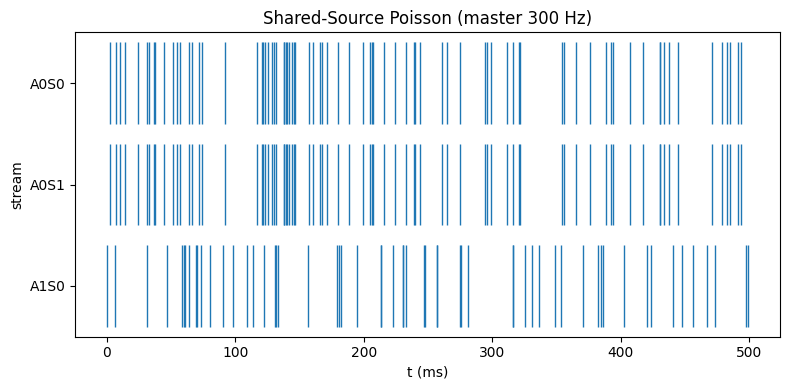

In [16]:
# 2 axons with 2 and 1 synapses respectively (total 3 output channels)
# SSPoissonEvents -> StochasticEventGenerator with FlatRateCurve (shared mode)
master_rate_hz = 300
n_synapses_per_axon = [2, 1]

gen = StochasticEventGenerator(
    rate_curves=FlatRateCurve(master_rate_hz),
    n_synapses_per_axon=n_synapses_per_axon,
    T_ms=T_ms,
    # seed=42,
)
events = gen.generate()
plotter = RasterPlotter(title=f"Shared-Source Poisson (master {master_rate_hz} Hz)")
plotter.add_streams(events)
plotter.show()

## SSPeriodicEvents

Shared-source periodic: deterministic timing with probabilistic routing.

/home/jordan/repos/toric_spines_sim/.venv/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


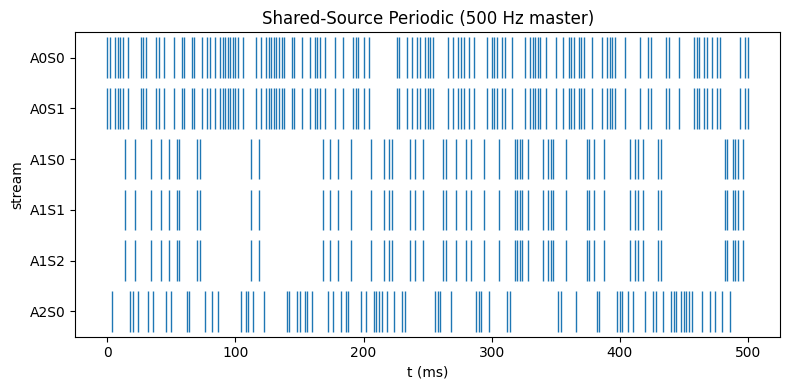

In [ ]:
# SSPeriodicEvents -> DeterministicEventGenerator with FlatRateCurve (shared mode)
master_rate_hz = 500
T_ms = 500.0

# Note: routing_mode is now "roundrobin" or "broadcast", not probabilistic weights
# For weighted distribution, use StochasticEventGenerator with routing_weights
gen = DeterministicEventGenerator(
    rate_curves=FlatRateCurve(master_rate_hz),
    n_synapses_per_axon=[2, 3, 1],
    T_ms=T_ms,
    routing_mode="roundrobin",  # deterministic round-robin distribution
)
events = gen.generate()
plotter = RasterPlotter(title=f"Shared-Source Periodic ({master_rate_hz} Hz master)")
plotter.add_streams(events)
plotter.show()

## SSSineRateEvents

Shared-source with sine-modulated rate. Events are more likely during peaks
of the sine wave (thinning algorithm).

/home/jordan/repos/toric_spines_sim/.venv/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


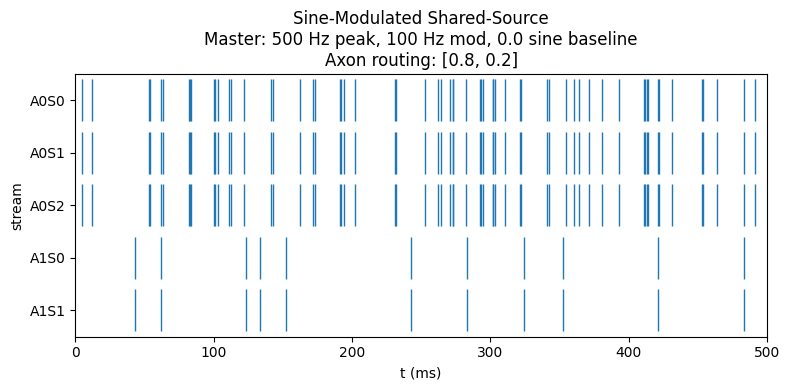

In [11]:
# SSSineRateEvents -> StochasticEventGenerator with SineRateCurve (shared mode)
master_rate_hz = 500
sine_frequency_hz = 100
T_ms = 500.0
baseline = 0.0

# Note: routing_weights replaced with probabilistic routing in StochasticEventGenerator
# For weighted routing, use routing_weights parameter
gen = StochasticEventGenerator(
    rate_curves=SineRateCurve(
        peak_rate_hz=master_rate_hz,
        freq_hz=sine_frequency_hz,
        baseline=baseline,
    ),
    n_synapses_per_axon=[3, 2],
    T_ms=T_ms,
    # seed=123,
)
events = gen.generate()

title = f"Sine-Modulated Shared-Source\nMaster: {master_rate_hz} Hz peak, {sine_frequency_hz} Hz mod, {baseline} sine baseline"
plotter = RasterPlotter(
    title=title,
    xlim=(0, 500.0),
    linewidth=1,
)
plotter.add_streams(events)
plotter.show()